# Домашнее задание 1

**Цель работы:** Провести комплексный анализ и сравнить эффективность четырех популярных реализаций градиентного бустинга (Scikit-Learn, XGBoost, CatBoost, LightGBM) на задаче предсказания оттока клиентов на датасете Telco Customer Churn.

**Структура работы:**
1. Разведочный анализ данных (EDA)
2. Препроцессинг и проектирование признаков (Feature Engineering)
3. Обучение моделей с параметрами "из коробки"
4. Настройка гиперпараметров (Hyperparameter Tuning) и сравнение


## Часть 1. Разведочный анализ данных (EDA)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля графиков
sns.set_theme(style="whitegrid")
# Загрузка данных
df = pd.read_csv('data.csv')
print("Первые 5 строк датасета:")
display(df.head())
print("Общая информация:")
df.info()


Первые 5 строк датасета:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [42]:
print("Пропуски:")
print(df.isnull().sum())

# Обработка неявных пропусков в TotalCharges (пустые строки)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
print(f"Найдено неявных пропусков в TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Заполняем пропуски медианой и приводим к числовому типу
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Удаляем customerID
df = df.drop(columns=['customerID'])


Пропуски:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Найдено неявных пропусков в TotalCharges: 11


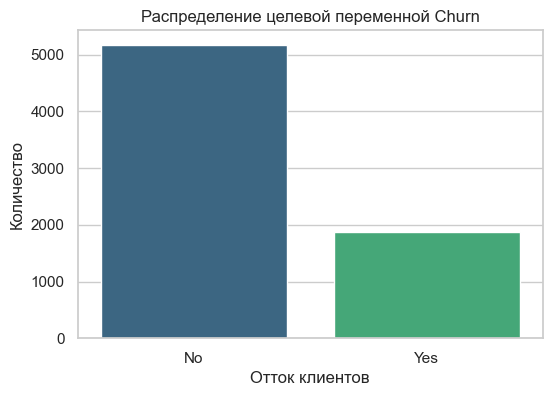

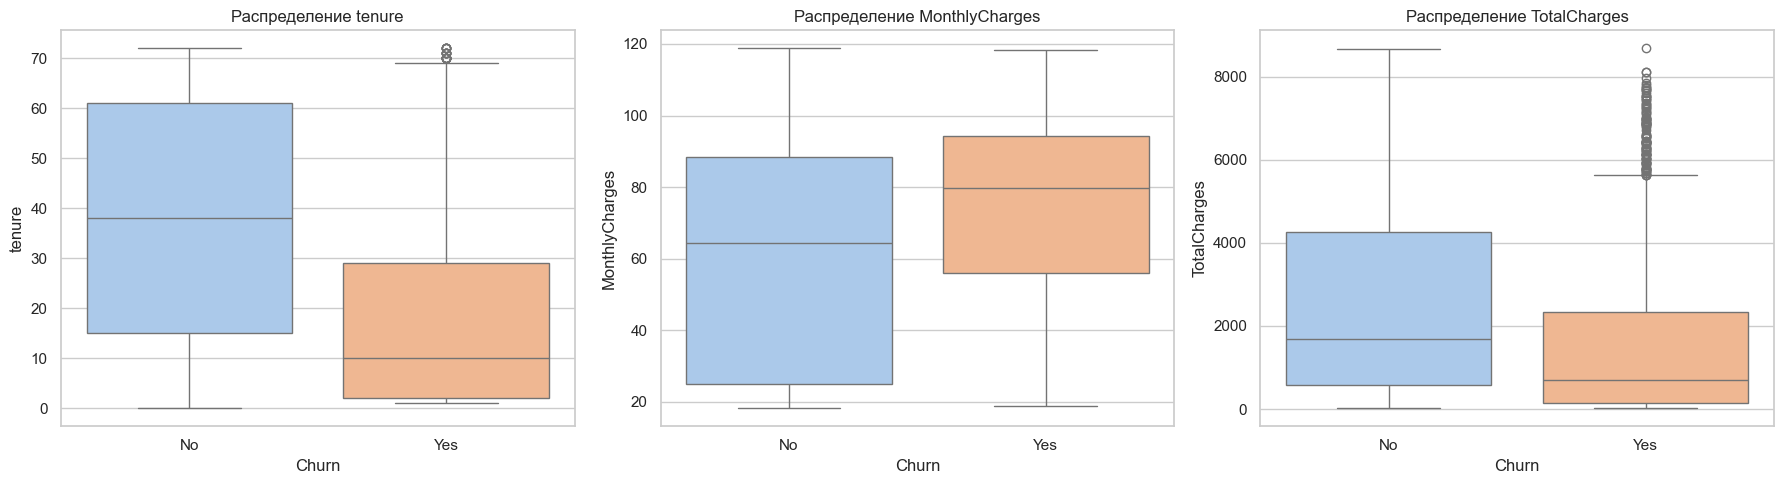

In [43]:
# Визуализация распределения целевой переменной Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title('Распределение целевой переменной Churn')
plt.xlabel('Отток клиентов')
plt.ylabel('Количество')
plt.show()

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(num_features):
    sns.boxplot(data=df, x='Churn', y=feature, ax=axes[i], hue='Churn', palette='pastel', legend=False)
    axes[i].set_title(f'Распределение {feature}')

plt.tight_layout()
plt.show()


## Часть 2. Preprocessing & Feature Engineering

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Копируем датасет для преобразований
df_preprocessed = df.copy()

# Выделяем категориальные признаки
categorical_cols = df_preprocessed.select_dtypes(include=['object', 'string', 'str']).columns

# Применяем LabelEncoder к категориальным переменным
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
    label_encoders[col] = le

display(df_preprocessed.head())


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [45]:
# Разделение на признаки (X) и цель (y)
X = df_preprocessed.drop(columns=['Churn'])
y = df_preprocessed['Churn']

# Разбиение на train и test (стратифицированная выборка)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (5634, 19)
Размер тестовой выборки: (1409, 19)


## Часть 3. Обучение моделей "из коробки"

In [46]:
# Импорт библиотек для бустинга
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Инициализация моделей с параметрами по умолчанию
models_default = {
    'Sklearn HistGB': HistGradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Обучение и оценка моделей
results_default = {}

print("Качество моделей 'из коробки' (ROC-AUC):")
for name, model in models_default.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_pred_proba)
    results_default[name] = score
    print(f"{name}: {score:.4f}")


Качество моделей 'из коробки' (ROC-AUC):
Sklearn HistGB: 0.8335
XGBoost: 0.8156
CatBoost: 0.8369
LightGBM: 0.8343


## Часть 4. Настройка гиперпараметров на кросс-валидации

In [47]:
from sklearn.model_selection import RandomizedSearchCV

# Словари гиперпараметров для оптимизации
param_grids = {
    'Sklearn HistGB': {
        'max_iter': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.9, 1.0]
    },
    'CatBoost': {
        'iterations': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [3, 5, 7]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.9, 1.0]
    }
}

results_tuned = {}

# Цикл оптимизации параметров
for name, model in models_default.items():
    print(f"Оптимизация {name}...")
    
    # Конфигурируем поиск
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    # Оценка лучшей модели на тестовой выборке
    best_model = search.best_estimator_
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_pred_proba)
    results_tuned[name] = score
    print(f"Лучшие параметры для {name}: {search.best_params_}")
    print(f"ROC-AUC настроенной модели: {score:.4f}\n")


Оптимизация Sklearn HistGB...
Лучшие параметры для Sklearn HistGB: {'max_iter': 150, 'max_depth': 3, 'learning_rate': 0.05}
ROC-AUC настроенной модели: 0.8457

Оптимизация XGBoost...
Лучшие параметры для XGBoost: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
ROC-AUC настроенной модели: 0.8465

Оптимизация CatBoost...
Лучшие параметры для CatBoost: {'learning_rate': 0.1, 'iterations': 150, 'depth': 3}
ROC-AUC настроенной модели: 0.8482

Оптимизация LightGBM...
Лучшие параметры для LightGBM: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
ROC-AUC настроенной модели: 0.8458



## Итоговое сравнение результатов
Построим финальную таблицу, чтобы определить победителя в этой битве алгоритмов бустинга.


,Модель,ROC-AUC (Из коробки),ROC-AUC (После тюнинга),Прирост качества
2,CatBoost,0.8369,0.8482,0.0113
1,XGBoost,0.8156,0.8465,0.0309
3,LightGBM,0.8343,0.8458,0.0115
0,Sklearn HistGB,0.8335,0.8457,0.0122


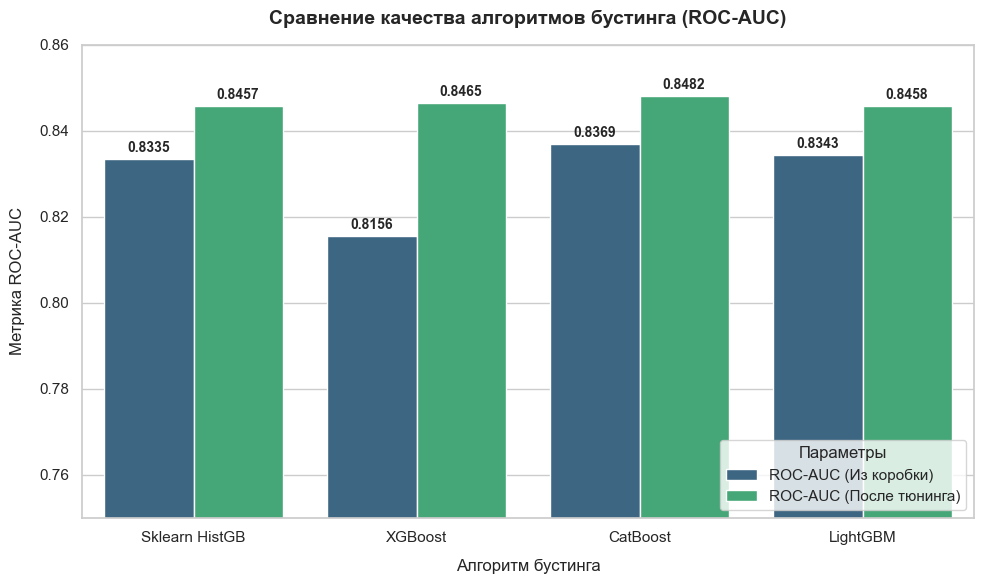

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Формирование финального отчета с исправленными именами колонок
df_comparison = pd.DataFrame({
    'Модель': list(results_default.keys()),
    'ROC-AUC (Из коробки)': list(results_default.values()),
    'ROC-AUC (После тюнинга)': list(results_tuned.values())
})

# Считаем прирост качества, используя точные названия колонок
df_comparison['Прирост качества'] = (
    df_comparison['ROC-AUC (После тюнинга)'] - df_comparison['ROC-AUC (Из коробки)']
)

# Выводим таблицу, отсортированную по убыванию финального качества
display(df_comparison.sort_values(by='ROC-AUC (После тюнинга)', ascending=False).round(4))

# Подготавливаем данные для Seaborn (переводим из широкого формата в длинный)
df_melted = df_comparison.melt(
    id_vars=['Модель'],
    value_vars=['ROC-AUC (Из коробки)', 'ROC-AUC (После тюнинга)'],
    var_name='Стадия обучения',
    value_name='ROC-AUC'
)

# Настраиваем стиль и размер графика
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Строим сдвоенный барплот
ax = sns.barplot(
    data=df_melted,
    x='Модель',
    y='ROC-AUC',
    hue='Стадия обучения',
    palette='viridis'
)

# Настраиваем отображение осей, чтобы разница была отчетливо видна
plt.ylim(0.75, 0.86)
plt.title('Сравнение качества алгоритмов бустинга (ROC-AUC)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Алгоритм бустинга', fontsize=12, labelpad=10)
plt.ylabel('Метрика ROC-AUC', fontsize=12, labelpad=10)
plt.legend(title='Параметры', loc='lower right')

# Добавляем текстовые метрики над каждым столбцом для идеальной наглядности
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Проверка на случай пустых значений
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


### Выводы:
На 1 месте CatBoost с результатом ROC-AUC = 0.8482. Модель показала лучшее качество как на дефолтных настройках (0.8369), так и после тюнинга. CatBoost блестяще справляется с табличными данными, содержащими большое количество закодированных категориальных признаков, благодаря продвинутым встроенным алгоритмам регуляризации.
XGBoost продемонстрировал мощный скачок в качестве, увеличив метрику на +0.0309 (с 0.8156 до 0.8465). Это доказывает, что XGBoost крайне чувствителен к базовым гиперпараметрам и требует обязательной ручной настройки для предотвращения недообучения или переобучения.
Все четыре алгоритма в процессе кросс-валидации сошлись на оптимальной глубине дерева, равной 3 вместо дефолтных 6. Это говорит о том, что структура связей в предоставленном датасете относительно несложная. Ограничение глубины помогло моделям избавиться от переобучения и улучшить обобщающую способность на тестовом датасете.